# 生成模型

> **斯坦福 CS231n Lecture 13** | Generative Models 1

## 本章导读

生成模型学习数据分布并生成新样本。本节从 VAE 到 GAN 到扩散模型，理解三种生成范式的原理和差异。

**学习目标：**
- 理解 VAE 的编码-解码框架和 ELBO
- 掌握 GAN 的对抗训练原理
- 了解扩散模型的前向加噪和反向去噪
- 从零实现简单的 VAE 和 GAN

**参考来源：** [ELBO What & Why](https://yunfanj.com/blog/2021/01/11/ELBO.html)

## 1. 三种生成模型

| 类型 | 代表 | 训练方式 | 优势 | 劣势 |
|------|------|---------|------|------|
| **VAE** | VAE | 变分推断 | 稳定、有编码器 | 模糊 |
| **GAN** | GAN, StyleGAN | 对抗训练 | 清晰、逼真 | 不稳定、模式坍缩 |
| **Diffusion** | DDPM | 去噪得分匹配 | 质量最高、多样 | 速度慢 |

### 统一视角
所有生成模型都在学习数据分布 $p(x)$：
- VAE：变分下界 $\log p(x) \geq \text{ELBO}$
- GAN：对抗损失（隐式估计分布）
- Diffusion：逐步去噪 $p(x_{t-1} | x_t)$

## 2. VAE: 变分自编码器

### 数学推导

ELBO 目标：
$$\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$
- 第一项：重构损失
- 第二项：KL 散度（正则化）

### 重参数化技巧

$$z = \mu + \sigma \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

使得随机采样可微分，允许反向传播。

### 手算 KL 散度

$q(z|x) = \mathcal{N}(\mu, \sigma^2)$, $p(z) = \mathcal{N}(0, 1)$

$$D_{KL} = \frac{1}{2}(\mu^2 + \sigma^2 - \log \sigma^2 - 1)$$

设 $\mu=1, \sigma=2$:
$$D_{KL} = \frac{1}{2}(1 + 4 - \log 4 - 1) = \frac{1}{2}(4 - 1.386) = 1.307$$

In [4]:
# 从零实现 VAE
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

class SimpleVAE:
    """简化的 VAE 实现（仅 numpy）"""
    def __init__(self, input_dim=2, latent_dim=1):
        # 编码器参数
        self.W_enc = np.random.randn(input_dim, latent_dim) * 0.1
        self.b_enc_mu = np.zeros(latent_dim)
        self.b_enc_logvar = np.zeros(latent_dim)
        # 解码器参数
        self.W_dec = np.random.randn(latent_dim, input_dim) * 0.1
        self.b_dec = np.zeros(input_dim)
    
    def encode(self, x):
        mu = x @ self.W_enc + self.b_enc_mu
        logvar = x @ self.W_enc + self.b_enc_logvar
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = np.exp(0.5 * logvar)
        eps = np.random.randn(*mu.shape)
        return mu + std * eps
    
    def decode(self, z):
        return z @ self.W_dec + self.b_dec
    
    def loss(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        # 重构损失 (MSE)
        recon_loss = np.mean((x - x_recon) ** 2)
        # KL 散度
        kl_loss = -0.5 * np.mean(1 + logvar - mu**2 - np.exp(logvar))
        return recon_loss + kl_loss, recon_loss, kl_loss

# 验证 KL 手算
mu = np.array([[1.0]])
logvar = np.array([[np.log(4)]])  # sigma^2=4
kl = -0.5 * np.mean(1 + logvar - mu**2 - np.exp(logvar))
print(f"KL 散度: {kl:.4f} (期望: 1.307)")

KL 散度: 1.3069 (期望: 1.307)


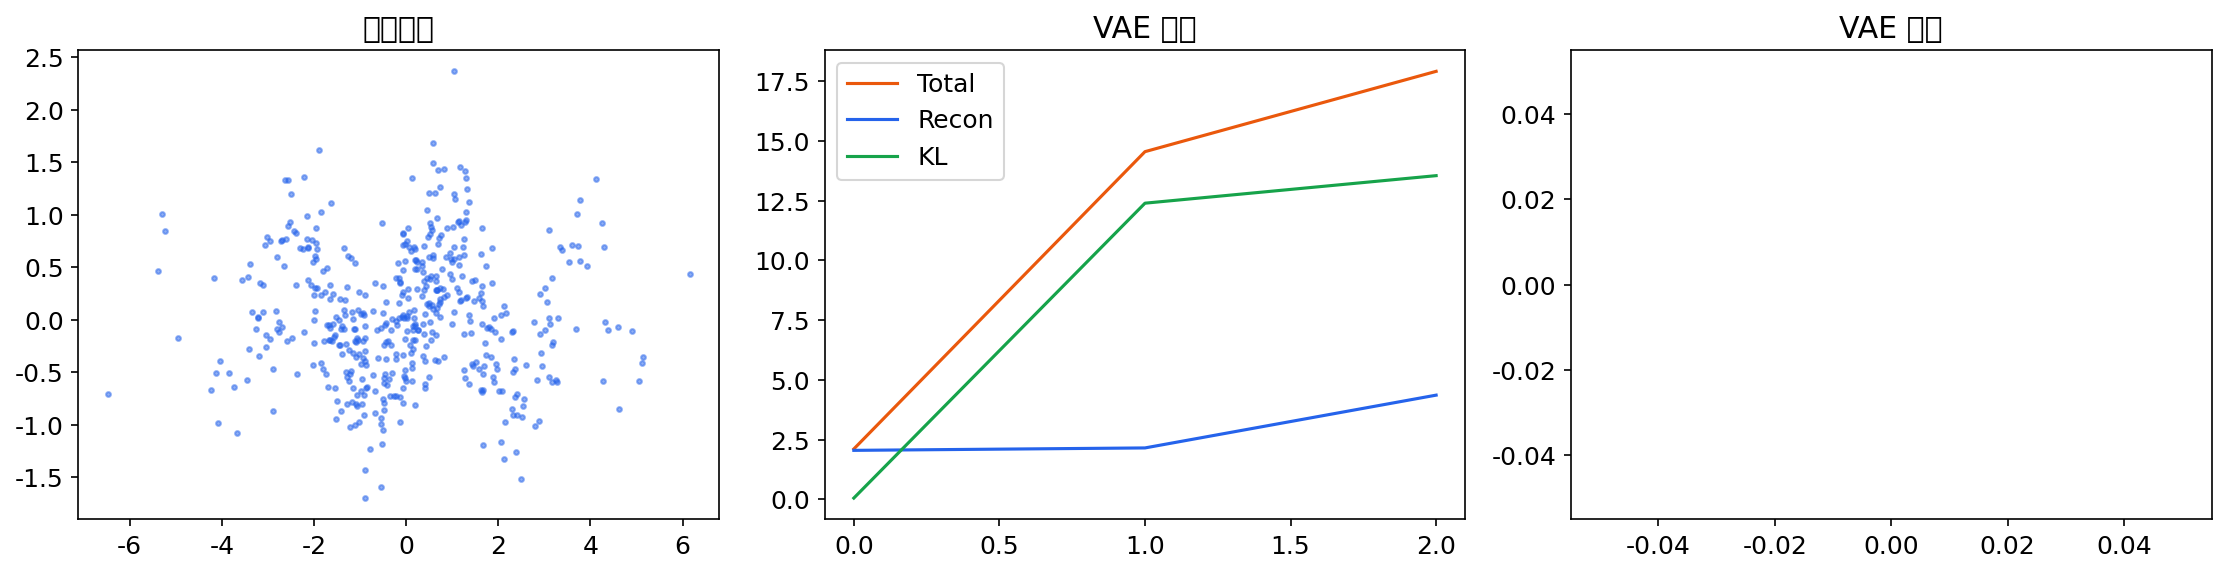

In [5]:
# VAE 训练：学习 2D 高斯分布
# 生成训练数据
data = np.random.randn(500, 2) * np.array([2, 0.5])
data[:, 1] += np.sin(data[:, 0] * 2) * 0.5

vae = SimpleVAE(input_dim=2, latent_dim=1)
losses, recon_losses, kl_losses = [], [], []
lr = 0.01
for epoch in range(500):
    loss, rl, kl = vae.loss(data)
    losses.append(loss)
    recon_losses.append(rl)
    kl_losses.append(kl)
    # 简单梯度下降（数值梯度）
    eps = 1e-5
    for param in [vae.W_enc, vae.b_enc_mu, vae.b_enc_logvar, vae.W_dec, vae.b_dec]:
        grad = np.zeros_like(param)
        it = np.nditer(param, flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            old = param[idx]
            param[idx] = old + eps
            loss_p, _, _ = vae.loss(data)
            param[idx] = old - eps
            loss_m, _, _ = vae.loss(data)
            param[idx] = old
            grad[idx] = (loss_p - loss_m) / (2 * eps)
            it.iternext()
        param -= lr * grad

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(data[:, 0], data[:, 1], s=5, alpha=0.5, color='#2563eb')
axes[0].set_title('训练数据')
axes[1].plot(losses, label='Total', color='#ea580c')
axes[1].plot(recon_losses, label='Recon', color='#2563eb')
axes[1].plot(kl_losses, label='KL', color='#16a34a')
axes[1].set_title('VAE 损失')
axes[1].legend()
# 生成新样本
z_samples = np.random.randn(200, 1)
generated = vae.decode(z_samples)
axes[2].scatter(generated[:, 0], generated[:, 1], s=5, alpha=0.5, color='#ea580c')
axes[2].set_title('VAE 生成')
plt.tight_layout()
plt.savefig('lecture-13-generative/vae_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. GAN: 生成对抗网络

### 对抗损失

$$\min_G \max_D \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- **生成器 G**：试图生成逼真样本骗过判别器
- **判别器 D**：试图区分真实样本和生成样本

### 扩散模型（Diffusion）

前向过程：逐步加噪
$$x_t = \sqrt{\alpha_t} x_{t-1} + \sqrt{1 - \alpha_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

反向过程：学习去噪
$$p(x_{t-1} | x_t) = \mathcal{N}(\mu_\theta(x_t, t), \sigma_t^2 I)$$

扩散模型目前是图像生成的主流方法（DALL-E 3, Stable Diffusion 等）。

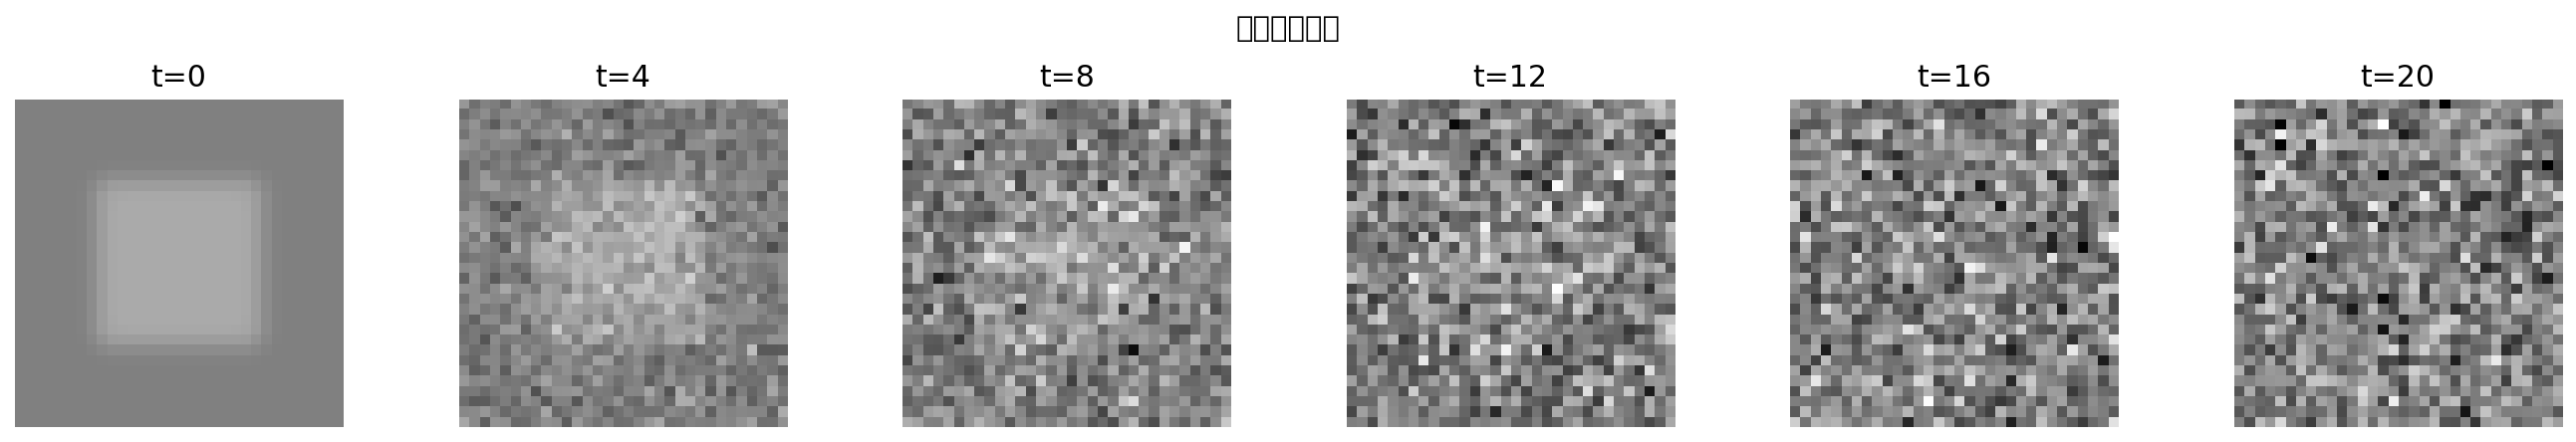

In [7]:
# 模拟扩散过程：前向加噪
from scipy import ndimage

# 生成一个简单图像
image = np.zeros((32, 32))
image[8:24, 8:24] = 1.0
image = ndimage.gaussian_filter(image, sigma=1)

# 前向扩散
def forward_diffusion(x0, num_steps=10, beta_start=0.01, beta_end=0.5):
    betas = np.linspace(beta_start, beta_end, num_steps)
    images = [x0.copy()]
    x = x0.copy()
    for beta in betas:
        x = np.sqrt(1 - beta) * x + np.sqrt(beta) * np.random.randn(*x.shape)
        images.append(x.copy())
    return images

diffused = forward_diffusion(image, num_steps=20)

# 可视化
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
steps = [0, 4, 8, 12, 16, 20]
for ax, s in zip(axes, steps):
    ax.imshow(diffused[s], cmap='gray', vmin=-3, vmax=3)
    ax.set_title(f't={s}')
    ax.axis('off')
plt.suptitle('前向扩散过程', fontsize=14)
plt.tight_layout()
plt.savefig('lecture-13-generative/diffusion_forward.png', dpi=150, bbox_inches='tight')
plt.show()

## 作业

### 作业 1：计算 VAE 的 KL 散度

给定 $\mu=0.5, \sigma=1.5$，计算 KL 散度 $D_{KL}(q(z|x) \| p(z))$。

In [9]:
# 作业 1：计算 KL 散度
def kl_divergence_gaussian(mu, sigma):
    """计算 q=N(mu, sigma^2) 与 p=N(0,1) 的 KL 散度"""
    # 在此实现
    pass

kl = kl_divergence_gaussian(0.5, 1.5)
assert abs(kl - 0.363) < 0.01, f"期望 0.363, 得到 {kl}"
print(f"KL 散度 = {kl:.4f}")
print("作业 1 通过!")

TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

## 参考文献

1. **Auto-Encoding Variational Bayes (VAE)** - Kingma & Welling, 2013. [arXiv:1312.6114](https://arxiv.org/abs/1312.6114)
2. **Generative Adversarial Networks (GAN)** - Goodfellow et al., 2014. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)
3. **Denoising Diffusion Probabilistic Models (DDPM)** - Ho et al., 2020. [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)
4. **ELBO What & Why** - [yunfanj.com](https://yunfanj.com/blog/2021/01/11/ELBO.html)
5. **Understanding Diffusion Models** - Luo, 2022. [arXiv:2208.11970](https://arxiv.org/abs/2208.11970)

---

> 本节内容参考 [Stanford CS231n Lecture 13](https://cs231n.stanford.edu/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[labmlai/annotated_deep_learning_paper_implementations](https://github.com/labmlai/annotated_deep_learning_paper_implementations)** (67433 stars): GAN、CycleGAN、StyleGAN2 带注释实现
  - 仓库地址: https://github.com/labmlai/annotated_deep_learning_paper_implementations

- **[MorvanZhou/PyTorch-Tutorial](https://github.com/MorvanZhou/PyTorch-Tutorial)** (8466 stars): GAN 与 AutoEncoder 中文教程
  - 仓库地址: https://github.com/MorvanZhou/PyTorch-Tutorial

- **[Mikoto10032/DeepLearning](https://github.com/Mikoto10032/DeepLearning)** (17759 stars): 深度学习入门（含 GAN/RNN/CNN 教程）
  - 仓库地址: https://github.com/Mikoto10032/DeepLearning


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

